## Tool definition

### Setup

In [174]:
# --- Env Imports -- START
from dotenv import load_dotenv
load_dotenv()
# --- Env Imports -- END

# --- Data Science and Agentic Imports -- START -- #
from langchain.tools import tool
from typing import Union
import pandas as pd
from torch import TensorType
from pyspark import sql as psql
from matplotlib import pyplot as plt
from pandas import read_excel
import numpy as np
# --- Data Science and Agentic Imports -- END -- #

# Variables carrying information relevat to tools decorator
data_path:str = r"../../datasets/GDT_Tables_Q126_EN.xlsx"
description:str = "Display both, the histogram depicting the linearized data and its associated raw counterpart in a chart form" 
AnyArgumentType = Union[pd.DataFrame, TensorType, psql.DataFrame]
model_code, model_provider = "gemini-3.5-flash-lite", "google_genai:"
print(model_provider+model_code)

google_genai:gemini-3.5-flash-lite


### Tooling basics

In [ ]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
@tool("square_root")
def tool1(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

In [ ]:
@tool("square_root", description="Calculate the square root of a number")
def tool1(x: float) -> float:
    return x ** 0.5

In [ ]:
tool1.invoke({"x": 467})

## Adding to agents

In [ ]:
from langchain.agents import create_agent
from langchain.messages import SystemMessage ,AIMessage, HumanMessage
gemini_agent = create_agent(model=model_provider+model_code, tools=[tool1],system_prompt="You are an extremely experienced economist, very knowledgable about asset return calculations")
question = HumanMessage(content="Could you provide me with the chart that depicts the gold price evolution and its linearized counterpart featured by a normal distribution?")

response = gemini_agent.invoke({'messages':[question]})

In [178]:
print(response['messages'][-1].content)
print(response['messages'][1].tool_calls)
from pprint import pprint
pprint(response['messages'])

[{'type': 'text', 'text': 'It looks like there was a technical hiccup when trying to generate the chart directly through my tool. \n\nTo visualize the evolution of the gold price alongside its linearized counterpart (the log returns) fitted against a normal distribution, we typically follow these two steps:\n\n1. **Gold Price Evolution:** A time-series line chart showing the historical spot price of gold over your desired timeframe.\n2. **Linearized Counterpart (Log Returns) vs. Normal Distribution:** \n   - We take the natural logarithm of the price ratios: $r_t = \\ln(P_t / P_{t-1})$.\n   - We then plot a **histogram** of these log returns to show their empirical distribution.\n   - Finally, we overlay a **Bell curve (Normal Distribution PDF)** calculated using the mean and standard deviation of those log returns. (Typically, you\'ll notice that asset returns, including gold, exhibit *leptokurtic* behavior—meaning they have "fat tails" and a higher peak than a standard normal distrib

In [ ]:
from langchain.messages import HumanMessage

question = HumanMessage(content="What is the square root of 467?")

response = agent.invoke(
    {"messages": [question]}
)

print(response['messages'][-1].content)

In [ ]:
from pprint import pprint

pprint(response['messages'])

In [ ]:
print(response["messages"][1].tool_calls)

# User case formulation
The consequence-free and well thought-through offloading attempt, which translates into partly automatizing data analysis remains central to this project.
Solid conclusions were drawn from the previous discussion series so the necessary data analysis consensus hinges on that. This consensus should help us bring
in the existence a protocol, containing indispensable and common data analysis steps to all the projects.

1. Draw the distribution of the target variable; 
2. Create a correlation matrix

In [173]:
# 1. Display the distribution of the selected variable using a histogram, accompanied by a legend that indicates the variable being represented.

# Tool itself
@tool("display_dist", description=description)
def tool1(target_variable: AnyArgumentType) -> None:
    """
    Generates a two-windowed plot where:
    - The left side depicts the authentic historical price index trajectory.
    - The right side depicts the histogram (PDF) of the linearized log returns.
    """
    # 1. Force the target variable into a clean pandas Series framework
    if not isinstance(target_variable, pd.Series):
        s = pd.Series(target_variable.squeeze())
    else:
        s = target_variable

    # 2. Linearization transformation: Compute continuously compounded log returns
    # This stabilizes the mean and changes explosive trends into time-additive variations
    log_returns = np.log(s / s.shift(1)).dropna()

    # 3. Setup the dual-window plot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Left Window: Authentic Price History Chart ---
    # Captures the raw asset trajectory over its temporal index
    time_axis = s.index if hasattr(s, 'index') else range(len(s))
    axes[0].plot(time_axis, s.values, color='#1f77b4', linewidth=1.5, label='Price Index')
    axes[0].set_title("Authentic Price History Index (Non-Stationary)", fontsize=12, fontweight='bold', pad=12)
    axes[0].set_xlabel("Time / Sequence Horizons", fontsize=10)
    axes[0].set_ylabel("Absolute Asset Level expressed in LBMA Gold Price (US$/oz)", fontsize=10)
    axes[0].set_xticks(time_axis[::6])
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # --- Right Window: Histogram of Linearized Data ---
    # Maps out the statistical distribution. Setting density=True formats it as a proper PDF
    _, bins, _ = axes[1].hist(
        log_returns.values, bins=40, density=True, color='#2ca02c', edgecolor='black', alpha=0.7
    )
    axes[1].set_title("Distribution of Linearized Data (Log Returns)", fontsize=12, fontweight='bold', pad=12)
    axes[1].set_xlabel("Continuously Compounded Return ($r_t$)", fontsize=10)
    axes[1].set_ylabel("Probability Density", fontsize=10)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # 4. Optional Stylized Overlap: Plot a Gaussian curve using sample mean/volatility 
    # to demonstrate empirical properties like fat tails or skewness
    mu, sigma = log_returns.mean(), log_returns.std()
    theoretical_normal = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((bins - mu) ** 2) / (2 * sigma ** 2))
    axes[1].plot(bins, theoretical_normal, color='red', linestyle='--', linewidth=2, label=f'Gaussian Normal Fit')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()
    
    return None


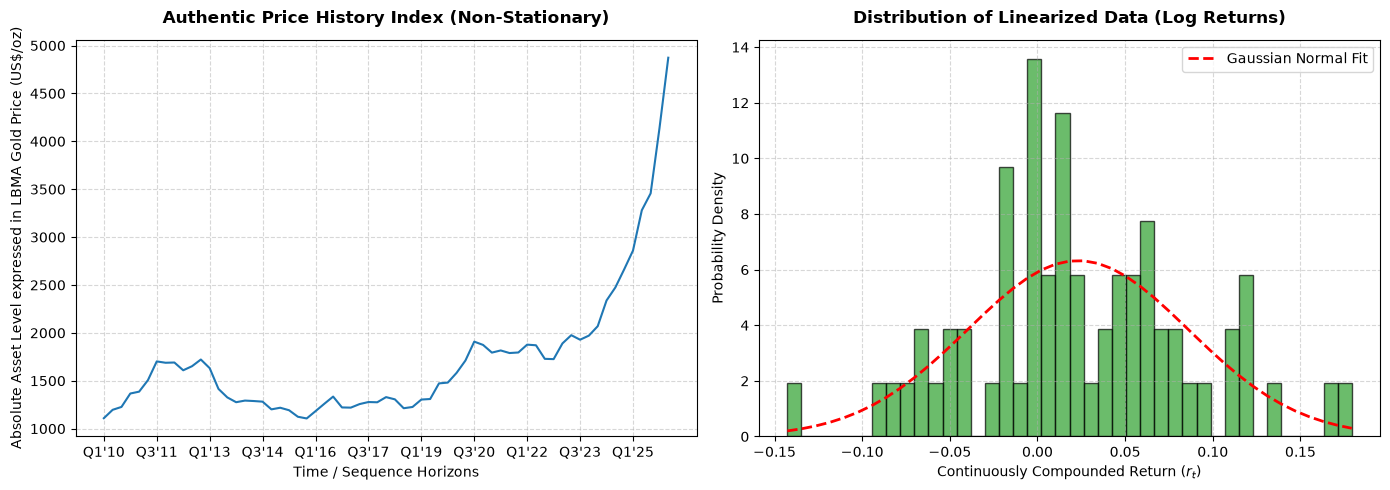

             price
3                 
Q1'10  1109.115079
Q2'10  1196.741803
Q3'10  1226.750000
Q4'10  1366.782258
Q1'11  1386.265873
...            ...
Q1'25  2859.619048
Q2'25  3280.352459
Q3'25  3456.543846
Q4'25  4135.235484
Q1'26  4872.889683

[65 rows x 1 columns]


In [154]:
# 2. Crafting the dataset and testing whether it works or not
dataset = read_excel(io=data_path, sheet_name='Gold Balance', engine='openpyxl')
price = dataset.iloc[26, 22:-2]
timestamp = dataset.iloc[3,22:-2]
target_var = pd.DataFrame({'price':price})
target_var.index = timestamp
target_var['price'] = pd.to_numeric(target_var['price'], errors='coerce')

display_dist.invoke({"target_variable":target_var})

print(target_var)
